# Analisis de resultados — `historial/results_22_07`

Notebook de lectura y exploracion de los resultados del sweep de experimentos
guardado en `historial/results_22_07` (snapshot congelado del 22/07/2026).

Lee, por **tipo de simetria** (`axis_sym` / `plane_sym`) y por **flujo/experimento**,
todas las metricas ya calculadas por `Mapping/evaluate.py` y `Mapping/compare_results.py`
(ver `docs/metricas_evaluacion.md` para la definicion exacta de cada una).

Fuentes que combina este notebook:

- `experiments_22_07_2026/all_experiments_comparison.csv` — tabla agregada, todas las
  filas (experimento x metodo x n_views) de ambos tipos de simetria.
- `experiments_22_07_2026/axis_sym_comparison.csv` / `plane_sym_comparison.csv` — el
  mismo contenido separado por tipo.
- `experiments_22_07_2026/rankings/*.csv` — rankings ya calculados (por AUC, por error
  angular, por SDE, y un ranking combinado), con metadata de `flow`/`clustering`/
  `patch_size`/`base_prompt` parseada del nombre del experimento.
- `per_experiment/<experimento>/experiments_*/*_comparison.csv` — detalle por
  experimento individual (mismas columnas, sin agregacion entre experimentos).
- `<experimento>/objects_good.json` / `objects_bad.json` / `objects_no_pred.json` —
  breakdown a nivel de objeto para los experimentos "flow" (A/B/C) de nivel superior.

**Nota sobre columnas `sde_*`/`auc_sde`/`precision_sde_*`**: en este snapshot corresponden
a la formula de SDE *propia* que `docs/actualizacion_metricas.md` documenta como
descontinuada en el `evaluate.py` actual. Se muestran igual porque son las que existen en
este historial; no confundir con `SDE_ref` (referencia externa), que no esta en estos CSVs.


In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# Ajustar si el notebook se mueve de lugar: se asume que corre desde la raiz del repo.
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "historial" / "results_22_07"
AGG_DIR = RESULTS_DIR / "experiments_22_07_2026"
RANKINGS_DIR = AGG_DIR / "rankings"

assert RESULTS_DIR.exists(), f"No se encontro {RESULTS_DIR}"
RESULTS_DIR


WindowsPath('c:/Users/HP/Desktop/Seminario de Tesis I/Symmetry-Detection-Using-Multimodal-Vision-Language-Models/historial/results_22_07')

## 1. Metadata de cada experimento

Los nombres de experimento codifican configuracion (prompt base, patch size, clustering, flow) pero no todas las filas de `all_experiments_comparison.csv` tienen esa metadata ya parseada (solo los rankings la traen armada para el subconjunto de experimentos "finales" del sweep). Se parsea con una regex para poder filtrar/agrupar cualquier fila.

In [2]:
def parse_experiment_name(name: str) -> dict:
    """Extrae metadata de un nombre de experimento tipo:
    axis_v05_1_flowC_p5, plane_v04_1_hdbscan_ms3, axis_v00_cluster, plane_v04_p3_cluster
    """
    flow_match = re.search(r"_flow([A-Z])", name)
    flow = flow_match.group(1) if flow_match else "A"  # sin sufijo => flow A (pipeline base)

    patch_match = re.search(r"_p(\d+)(?:_|$)", name)
    patch_size = int(patch_match.group(1)) if patch_match else None

    if "_hdbscan_ms" in name:
        ms_match = re.search(r"_hdbscan_ms(\d+)", name)
        clustering = f"hdbscan_ms{ms_match.group(1)}" if ms_match else "hdbscan"
    elif re.search(r"_cluster(?:_|$)", name):
        clustering = "cluster"
    else:
        clustering = "none"

    base_prompt = name
    for pat in [r"_flow[A-Z]", r"_p\d+", r"_hdbscan_ms\d+", r"_cluster"]:
        base_prompt = re.sub(pat, "", base_prompt)

    return {
        "base_prompt": base_prompt,
        "flow": flow,
        "clustering": clustering,
        "patch_size": patch_size,
    }


def enrich_with_metadata(df: pd.DataFrame, name_col: str = "experiment") -> pd.DataFrame:
    meta = df[name_col].apply(parse_experiment_name).apply(pd.Series)
    return pd.concat([df, meta], axis=1)


## 2. Carga de las tablas agregadas

In [3]:
all_df = pd.read_csv(AGG_DIR / "all_experiments_comparison.csv")
all_df = enrich_with_metadata(all_df)

axis_df = all_df[all_df["symmetry_type"] == "axis_sym"].copy()
plane_df = all_df[all_df["symmetry_type"] == "plane_sym"].copy()

print(f"Total filas: {len(all_df)}  (axis_sym={len(axis_df)}, plane_sym={len(plane_df)})")
print(f"Experimentos unicos: {all_df['experiment'].nunique()}")
print(f"Metodos: {sorted(all_df['method'].unique())}")
print(f"n_views: {sorted(all_df['n_views'].unique())}")
all_df.head(3)


Total filas: 2148  (axis_sym=1068, plane_sym=1080)
Experimentos unicos: 143
Metodos: ['ransac_svd', 'ransac_svd_sde', 'svd', 'svd_sde']
n_views: [np.int64(1), np.int64(6), np.int64(14), np.int64(26)]


,symmetry_type,experiment,method,n_views,n_total,n_objects,angular_error_mean,angular_error_median,angular_error_std,translation_error_mean,translation_error_median,translation_error_std,auc_angular,n_points_mean,precision_5deg,precision_10deg,precision_15deg,sde_mean,sde_median,sde_std,auc_sde,precision_sde_010,precision_sde_020,base_prompt,flow,clustering,patch_size
0,axis_sym,axis_v00_cluster,ransac_svd_sde,1,850,70,87.4030,90.0000,13.0164,0.067620,0.059454,0.052759,0.0196,2.00,0.0047,0.0141,0.0188,NaN,NaN,NaN,NaN,NaN,NaN,axis_v00,A,cluster,NaN
1,axis_sym,axis_v00_cluster,ransac_svd_sde,6,850,538,64.6510,81.8432,30.8889,0.080399,0.060745,0.069660,0.1602,4.88,0.0318,0.1047,0.1306,NaN,NaN,NaN,NaN,NaN,NaN,axis_v00,A,cluster,NaN
2,axis_sym,axis_v00_cluster,ransac_svd_sde,14,850,655,56.6934,67.6745,32.8650,0.090506,0.064752,0.078011,0.2275,8.62,0.0518,0.1365,0.1988,NaN,NaN,NaN,NaN,NaN,NaN,axis_v00,A,cluster,NaN


In [4]:
# Metricas disponibles por tipo de simetria (columnas no completamente NaN)
for name, df in [("axis_sym", axis_df), ("plane_sym", plane_df)]:
    metric_cols = [c for c in df.columns if df[c].notna().any() and c not in
                   {"symmetry_type", "experiment", "method", "n_views", "n_total",
                    "n_objects", "base_prompt", "flow", "clustering", "patch_size"}]
    print(f"{name}: {metric_cols}")


axis_sym: ['angular_error_mean', 'angular_error_median', 'angular_error_std', 'translation_error_mean', 'translation_error_median', 'translation_error_std', 'auc_angular', 'n_points_mean', 'precision_5deg', 'precision_10deg', 'precision_15deg']
plane_sym: ['angular_error_mean', 'angular_error_median', 'angular_error_std', 'translation_error_mean', 'translation_error_median', 'translation_error_std', 'auc_angular', 'n_points_mean', 'precision_5deg', 'precision_10deg', 'precision_15deg', 'sde_mean', 'sde_median', 'sde_std', 'auc_sde', 'precision_sde_010', 'precision_sde_020']


## 3. Rankings ya calculados

Estos CSVs traen la metadata de `flow`/`clustering`/`patch_size` ya parseada por `compare_results.py` (para el subconjunto de experimentos incluidos en el ranking final del sweep) y muestran, por experimento, la mejor fila (mayor `n_views` con metodo `svd_sde`/similar).

In [5]:
rankings = {}
for f in sorted(RANKINGS_DIR.glob("*.csv")):
    rankings[f.stem] = pd.read_csv(f)

for name, df in rankings.items():
    print(f"--- {name} ({len(df)} filas) ---")
    display(df.head(5))


--- axis_sym_ranking_angular_error (72 filas) ---


,experiment,base_prompt,flow,clustering,patch_size,method,n_views,n_objects,angular_error_mean
0,axis_v05_1_flowC_p5,axis_v05_1,C,none,5,svd_sde,26,835,39.3026
1,axis_v05_1_flowC_p3,axis_v05_1,C,none,3,svd_sde,26,829,40.5276
2,axis_v05_1_flowC,axis_v05_1,C,none,1,svd_sde,26,816,43.0070
3,axis_v05_1_p5,axis_v05_1,A,none,5,svd_sde,26,771,43.4657
4,axis_v05_1_flowC_cluster,axis_v05_1,C,greedy,1,svd_sde,26,814,43.5616


--- axis_sym_ranking_auc (72 filas) ---


,experiment,base_prompt,flow,clustering,patch_size,method,n_views,n_objects,auc_angular
0,axis_v05_1_flowC_p5,axis_v05_1,C,none,5,svd_sde,26,835,0.4369
1,axis_v05_1_flowC_p3,axis_v05_1,C,none,3,svd_sde,26,829,0.4197
2,axis_v05_1_flowB_p5,axis_v05_1,B,none,5,svd_sde,26,769,0.4039
3,axis_v05_1_p5_cluster,axis_v05_1,A,greedy,5,svd_sde,26,769,0.4024
4,axis_v05_1_p5,axis_v05_1,A,none,5,svd_sde,26,771,0.3994


--- axis_sym_ranking_combined (72 filas) ---


...

,experiment,base_prompt,flow,clustering,patch_size,method,n_views,n_objects,auc_angular
0,plane_v04_1_flowB,plane_v04_1,B,none,1,ransac_svd_sde,1,644,0.5790
1,plane_v04_1_hdbscan_ms5,plane_v04_1,A,hdbscan_ms5,1,ransac_svd_sde,1,641,0.5733
2,plane_v04_1_cluster,plane_v04_1,A,greedy,1,ransac_svd_sde,1,641,0.5733
3,plane_v04_1_hdbscan_ms2,plane_v04_1,A,hdbscan_ms2,1,ransac_svd_sde,1,641,0.5733
4,plane_v04_1_hdbscan_ms3,plane_v04_1,A,hdbscan_ms3,1,ransac_svd_sde,1,641,0.5733


--- plane_sym_ranking_combined (71 filas) ---


,experiment,base_prompt,flow,clustering,patch_size,method,n_views,n_objects,auc_angular,sde_mean,combined_rank
0,plane_v04_p5,plane_v04,A,none,5,svd_sde,6,846,0.3464,0.224231,496.0
1,plane_v02_p5,plane_v02,A,none,5,svd_sde,6,839,0.3200,0.218707,524.0
2,plane_v04_p3,plane_v04,A,none,3,svd_sde,6,842,0.3755,0.241093,530.0
3,plane_v02_p3,plane_v02,A,none,3,svd_sde,6,832,0.3431,0.230088,534.0
4,plane_v02,plane_v02,A,none,1,svd_sde,6,821,0.3621,0.245293,560.0


--- plane_sym_ranking_sde (71 filas) ---


,experiment,base_prompt,flow,clustering,patch_size,method,n_views,n_objects,sde_mean
0,plane_v04_1_flowC_p5,plane_v04_1,C,none,5,svd_sde,26,847,0.165462
1,plane_v04_1_flowC_p3,plane_v04_1,C,none,3,svd_sde,26,846,0.168500
2,plane_v00_1_p5,plane_v00_1,A,none,5,svd_sde,26,797,0.168665
3,plane_v00_1_p3,plane_v00_1,A,none,3,svd_sde,26,785,0.171433
4,plane_v04_1_flowC,plane_v04_1,C,none,1,svd_sde,26,844,0.171699


## 4. Metricas por tipo de simetria y flujo (A/B/C)

Comparacion agregada usando los rankings combinados, que ya traen `flow` identificado. Flow A = pipeline original (con malla, ray casting); B/C = variantes del pipeline sin malla (ver `docs/pipeline_sin_malla.md`).

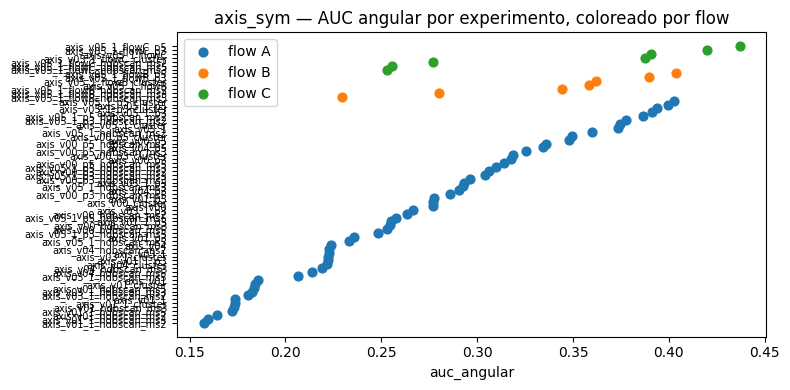

In [6]:
def plot_metric_by_flow(ranking_df: pd.DataFrame, metric: str, title: str):
    fig, ax = plt.subplots(figsize=(8, 4))
    for flow, sub in ranking_df.groupby("flow"):
        sub_sorted = sub.sort_values(metric)
        ax.scatter(sub_sorted[metric], sub_sorted["experiment"], label=f"flow {flow}", s=40)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    plt.show()


plot_metric_by_flow(rankings["axis_sym_ranking_auc"], "auc_angular",
                     "axis_sym — AUC angular por experimento, coloreado por flow")


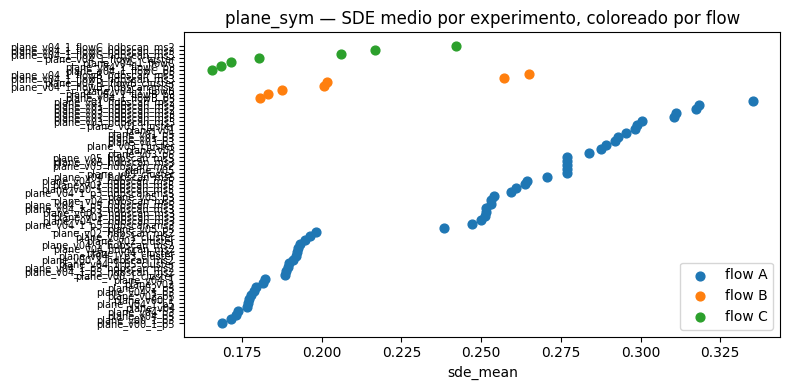

In [7]:
plot_metric_by_flow(rankings["plane_sym_ranking_sde"], "sde_mean",
                     "plane_sym — SDE medio por experimento, coloreado por flow")


In [8]:
# Resumen: mejor experimento por flow segun cada ranking disponible
for name, df in rankings.items():
    if "flow" not in df.columns:
        continue
    metric_col = [c for c in ["auc_angular", "angular_error_mean", "sde_mean", "combined_rank"]
                  if c in df.columns][0]
    ascending = metric_col in {"angular_error_mean", "sde_mean", "combined_rank"}
    best_per_flow = (df.sort_values(metric_col, ascending=ascending)
                        .groupby("flow").first()[["experiment", metric_col]])
    print(f"--- {name}: mejor experimento por flow (orden por {metric_col}) ---")
    display(best_per_flow)


--- axis_sym_ranking_angular_error: mejor experimento por flow (orden por angular_error_mean) ---


,experiment,angular_error_mean
flow,,
A,axis_v05_1_p5,43.4657
B,axis_v05_1_flowB_p5,43.6172
C,axis_v05_1_flowC_p5,39.3026


--- axis_sym_ranking_auc: mejor experimento por flow (orden por auc_angular) ---


,experiment,auc_angular
flow,,
A,axis_v05_1_p5_cluster,0.4024
B,axis_v05_1_flowB_p5,0.4039
C,axis_v05_1_flowC_p5,0.4369


--- axis_sym_ranking_combined: mejor experimento por flow (orden por auc_angular) ---


...

,experiment,auc_angular
flow,,
A,plane_v04_1_hdbscan_ms5,0.5733
B,plane_v04_1_flowB,0.5790
C,plane_v04_1_flowC_hdbscan_ms2,0.2558


--- plane_sym_ranking_combined: mejor experimento por flow (orden por auc_angular) ---


,experiment,auc_angular
flow,,
A,plane_v04_1_p5_hdbscan_ms3,0.5098
B,plane_v04_1_flowB,0.3535
C,plane_v04_1_flowC_hdbscan_ms2,0.2558


--- plane_sym_ranking_sde: mejor experimento por flow (orden por sde_mean) ---


,experiment,sde_mean
flow,,
A,plane_v00_1_p5,0.168665
B,plane_v04_1_flowB_p5,0.180746
C,plane_v04_1_flowC_p5,0.165462


## 5. Top experimentos por metrica (todo el sweep)

Usando `all_experiments_comparison.csv` completo (no solo el subconjunto de rankings), filtrando a una cantidad de vistas representativa para que la comparacion entre experimentos sea justa.

In [9]:
def top_n_by_metric(df: pd.DataFrame, metric: str, n_views: int, top: int = 10,
                     ascending: bool = False) -> pd.DataFrame:
    sub = df[df["n_views"] == n_views].dropna(subset=[metric])
    cols = ["experiment", "method", "flow", "clustering", "patch_size", "n_objects", metric]
    return sub.sort_values(metric, ascending=ascending)[cols].head(top)


N_VIEWS_REF = 26  # vista "full grid" tipica del sweep; ajustar segun lo que se quiera comparar

print("axis_sym — mejor AUC angular")
display(top_n_by_metric(axis_df, "auc_angular", N_VIEWS_REF, ascending=False))

print("axis_sym — menor error angular medio")
display(top_n_by_metric(axis_df, "angular_error_mean", N_VIEWS_REF, ascending=True))


axis_sym — mejor AUC angular


,experiment,method,flow,clustering,patch_size,n_objects,auc_angular
823,axis_v05_1_flowC_p5,svd_sde,C,none,5.0,835,0.4369
827,axis_v05_1_flowC_p5,svd,C,none,5.0,835,0.4369
807,axis_v05_1_flowC_p3,svd_sde,C,none,3.0,829,0.4197
811,axis_v05_1_flowC_p3,svd,C,none,3.0,829,0.4197
711,axis_v05_1_flowB_p5,svd_sde,B,none,5.0,769,0.4039
715,axis_v05_1_flowB_p5,svd,B,none,5.0,769,0.4039
987,axis_v05_1_p5_cluster,svd,A,cluster,5.0,769,0.4024
983,axis_v05_1_p5_cluster,svd_sde,A,cluster,5.0,769,0.4024
1051,axis_v05_1_p5,svd,A,none,5.0,771,0.3994
1047,axis_v05_1_p5,svd_sde,A,none,5.0,771,0.3994


axis_sym — menor error angular medio


,experiment,method,flow,clustering,patch_size,n_objects,angular_error_mean
823,axis_v05_1_flowC_p5,svd_sde,C,none,5.0,835,39.3026
827,axis_v05_1_flowC_p5,svd,C,none,5.0,835,39.3026
807,axis_v05_1_flowC_p3,svd_sde,C,none,3.0,829,40.5276
811,axis_v05_1_flowC_p3,svd,C,none,3.0,829,40.5276
843,axis_v05_1_flowC,svd,C,none,NaN,816,43.0070
839,axis_v05_1_flowC,svd_sde,C,none,NaN,816,43.0070
1047,axis_v05_1_p5,svd_sde,A,none,5.0,771,43.4657
1051,axis_v05_1_p5,svd,A,none,5.0,771,43.4657
743,axis_v05_1_flowC_cluster,svd_sde,C,cluster,NaN,814,43.5616
747,axis_v05_1_flowC_cluster,svd,C,cluster,NaN,814,43.5616


In [10]:
print("plane_sym — mejor AUC angular")
display(top_n_by_metric(plane_df, "auc_angular", N_VIEWS_REF, ascending=False))

print("plane_sym — menor SDE medio (propio, ver nota metodologica arriba)")
display(top_n_by_metric(plane_df, "sde_mean", N_VIEWS_REF, ascending=True))


plane_sym — mejor AUC angular


,experiment,method,flow,clustering,patch_size,n_objects,auc_angular
1242,plane_v01_p5,ransac_svd_sde,A,none,5.0,743,0.3520
1245,plane_v01_p5,ransac_svd,A,none,5.0,743,0.3520
1251,plane_v01_p5,svd,A,none,5.0,743,0.3222
1248,plane_v01_p5,svd_sde,A,none,5.0,743,0.3222
1233,plane_v01_p3,ransac_svd,A,none,3.0,712,0.3171
1230,plane_v01_p3,ransac_svd_sde,A,none,3.0,712,0.3171
1743,plane_v04_1_hdbscan_ms5,svd_sde,A,hdbscan_ms5,NaN,755,0.3081
1747,plane_v04_1_hdbscan_ms5,svd,A,hdbscan_ms5,NaN,755,0.3081
1239,plane_v01_p3,svd,A,none,3.0,712,0.3072
1236,plane_v01_p3,svd_sde,A,none,3.0,712,0.3072


plane_sym — menor SDE medio (propio, ver nota metodologica arriba)


,experiment,method,flow,clustering,patch_size,n_objects,sde_mean
1679,plane_v04_1_flowC_p5,svd_sde,C,none,5.0,847,0.165462
1683,plane_v04_1_flowC_p5,svd,C,none,5.0,847,0.165462
1663,plane_v04_1_flowC_p3,svd_sde,C,none,3.0,846,0.168500
1667,plane_v04_1_flowC_p3,svd,C,none,3.0,846,0.168500
1159,plane_v00_1_p5,svd_sde,A,none,5.0,797,0.168665
1163,plane_v00_1_p5,svd,A,none,5.0,797,0.168665
1143,plane_v00_1_p3,svd_sde,A,none,3.0,785,0.171433
1147,plane_v00_1_p3,svd,A,none,3.0,785,0.171433
1699,plane_v04_1_flowC,svd,C,none,NaN,844,0.171699
1695,plane_v04_1_flowC,svd_sde,C,none,NaN,844,0.171699


## 6. Metrica vs. numero de vistas, por flujo

Como evoluciona cada metrica al aumentar `n_views`, separado por flow. Sirve para ver si mas vistas realmente ayuda o si el pipeline satura/degrada (ver `docs/metricas_evaluacion.md` sobre imputacion de objetos sin prediccion a 90 grados).

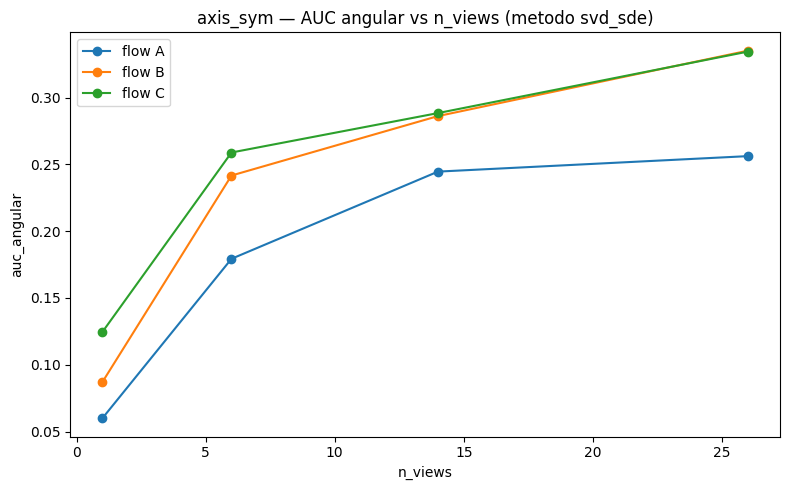

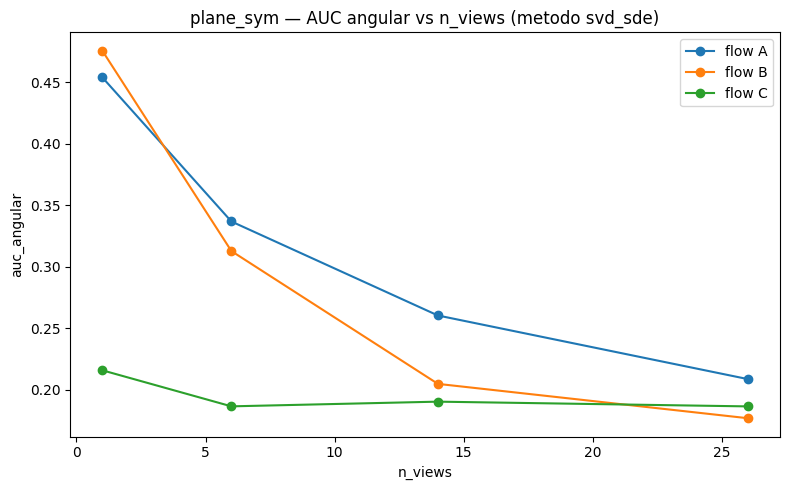

In [11]:
def plot_metric_vs_views(df: pd.DataFrame, metric: str, title: str, method: str = "svd_sde"):
    sub = df[df["method"] == method]
    fig, ax = plt.subplots(figsize=(8, 5))
    for flow, g in sub.groupby("flow"):
        agg = g.groupby("n_views")[metric].mean().sort_index()
        ax.plot(agg.index, agg.values, marker="o", label=f"flow {flow}")
    ax.set_xlabel("n_views")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_metric_vs_views(axis_df, "auc_angular", "axis_sym — AUC angular vs n_views (metodo svd_sde)")
plot_metric_vs_views(plane_df, "auc_angular", "plane_sym — AUC angular vs n_views (metodo svd_sde)")


## 7. Drill-down: detalle por experimento individual (metodo x n_views)

Cada experimento tiene su propio CSV en `per_experiment/<experimento>/experiments_*/<...>_comparison.csv` con el detalle completo (todas las combinaciones de metodo x n_views). Util para comparar `svd` vs `svd_sde` vs `ransac_svd` vs `ransac_svd_sde` dentro de un mismo experimento.

In [12]:
def load_experiment_detail(symmetry_type: str, experiment: str) -> pd.DataFrame:
    exp_dir = RESULTS_DIR / symmetry_type / "per_experiment" / experiment
    csvs = list(exp_dir.glob("experiments_*/*_comparison.csv"))
    if not csvs:
        raise FileNotFoundError(f"No se encontro CSV de detalle para {symmetry_type}/{experiment}")
    return pd.read_csv(csvs[0])


def list_available_experiments(symmetry_type: str) -> list:
    base = RESULTS_DIR / symmetry_type / "per_experiment"
    return sorted(p.name for p in base.iterdir() if p.is_dir())


print("Experimentos disponibles (axis_sym), primeros 15:")
print(list_available_experiments("axis_sym")[:15])


Experimentos disponibles (axis_sym), primeros 15:
['axis_v00', 'axis_v00_cluster', 'axis_v00_full_grid', 'axis_v00_hdbscan_ms2', 'axis_v00_hdbscan_ms3', 'axis_v00_hdbscan_ms5', 'axis_v00_p3', 'axis_v00_p5', 'axis_v01', 'axis_v01_1', 'axis_v01_1_cluster', 'axis_v01_1_hdbscan_ms2', 'axis_v01_1_hdbscan_ms3', 'axis_v01_1_hdbscan_ms5', 'axis_v01_1_p3']


In [13]:
EXPERIMENT_TO_INSPECT = "axis_v00"  # cambiar por cualquier nombre de list_available_experiments(...)

detail = load_experiment_detail("axis_sym", EXPERIMENT_TO_INSPECT)
display(detail)


,experiment,method,n_views,n_total,n_objects,angular_error_mean,angular_error_median,angular_error_std,translation_error_mean,translation_error_median,translation_error_std,auc_angular,n_points_mean,precision_5deg,precision_10deg,precision_15deg
0,axis_v00,ransac_svd_sde,1,850,70,87.4030,90.0000,13.0164,0.067620,0.059454,0.052759,0.0196,2.00,0.0047,0.0141,0.0188
1,axis_v00,ransac_svd_sde,6,850,547,63.4828,80.6838,31.2402,0.079958,0.062596,0.068077,0.1695,6.42,0.0318,0.1082,0.1353
2,axis_v00,ransac_svd_sde,14,850,664,56.4624,66.1753,32.6389,0.086137,0.062369,0.077055,0.2256,12.51,0.0565,0.1282,0.1941
3,axis_v00,ransac_svd_sde,26,850,506,66.4612,87.8471,31.8479,0.093575,0.068800,0.083133,0.1664,14.49,0.0365,0.1082,0.1482
4,axis_v00,ransac_svd,1,850,70,87.4030,90.0000,13.0164,0.067620,0.059454,0.052759,0.0196,2.00,0.0047,0.0141,0.0188
5,axis_v00,ransac_svd,6,850,547,63.4828,80.6838,31.2402,0.079958,0.062596,0.068077,0.1695,6.42,0.0318,0.1082,0.1353
6,axis_v00,ransac_svd,14,850,664,56.4624,66.1753,32.6389,0.086137,0.062369,0.077055,0.2256,12.51,0.0565,0.1282,0.1941
7,axis_v00,ransac_svd,26,850,506,66.4612,87.8471,31.8479,0.093575,0.068800,0.083133,0.1664,14.49,0.0365,0.1082,0.1482
8,axis_v00,svd_sde,1,850,70,87.4030,90.0000,13.0164,0.067620,0.059454,0.052759,0.0196,2.00,0.0047,0.0141,0.0188
9,axis_v00,svd_sde,6,850,547,61.8075,81.3477,33.0335,0.049080,0.037276,0.043993,0.2000,6.42,0.0541,0.1459,0.1753


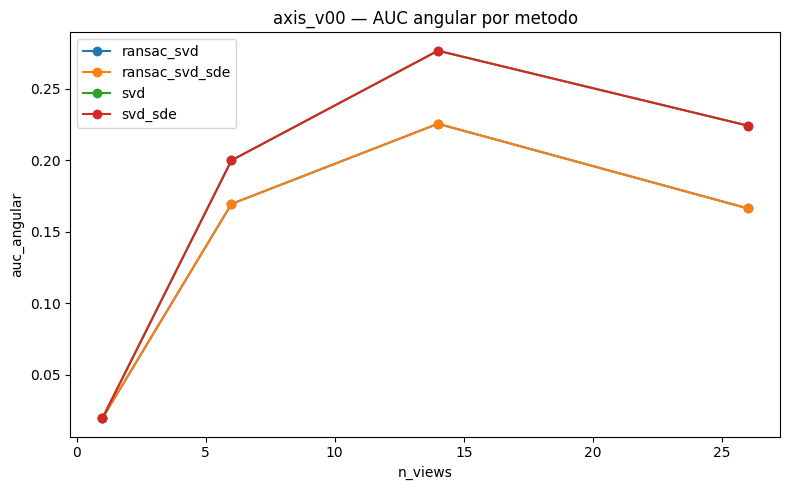

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for method, g in detail.groupby("method"):
    g_sorted = g.sort_values("n_views")
    ax.plot(g_sorted["n_views"], g_sorted["auc_angular"], marker="o", label=method)
ax.set_xlabel("n_views")
ax.set_ylabel("auc_angular")
ax.set_title(f"{EXPERIMENT_TO_INSPECT} — AUC angular por metodo")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Breakdown a nivel de objeto (experimentos "flow" de nivel superior)

Los experimentos `axis_v05_1_flowB`, `axis_v05_1_flowC`, `plane_v04_1`, `plane_v04_1_flowB`, `plane_v04_1_flowC` (carpetas de nivel superior en `results_22_07/`, no dentro de `per_experiment/`) guardan ademas un breakdown por objeto: `objects_good.json` / `objects_bad.json` / `objects_no_pred.json`.

In [15]:
def load_object_breakdown(experiment_dir_name: str) -> pd.DataFrame:
    exp_dir = RESULTS_DIR / experiment_dir_name
    frames = []
    for label in ["good", "bad", "no_pred"]:
        f = exp_dir / f"objects_{label}.json"
        if not f.exists():
            continue
        data = json.loads(f.read_text(encoding="utf-8"))
        df = pd.DataFrame(data)
        df["quality"] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


TOP_LEVEL_FLOW_DIRS = [
    "axis_v05_1_flowB", "axis_v05_1_flowC",
    "plane_v04_1", "plane_v04_1_flowB", "plane_v04_1_flowC",
]

for exp_name in TOP_LEVEL_FLOW_DIRS:
    obj_df = load_object_breakdown(exp_name)
    if obj_df.empty:
        continue
    counts = obj_df["quality"].value_counts()
    print(f"{exp_name}: {dict(counts)}")


axis_v05_1_flowB: {'no_pred': np.int64(53), 'good': np.int64(10), 'bad': np.int64(10)}
axis_v05_1_flowC: {'no_pred': np.int64(42), 'good': np.int64(10), 'bad': np.int64(10)}
plane_v04_1: {'no_pred': np.int64(209), 'good': np.int64(10), 'bad': np.int64(10)}
plane_v04_1_flowB: {'no_pred': np.int64(13), 'good': np.int64(10), 'bad': np.int64(10)}
plane_v04_1_flowC: {'good': np.int64(10), 'bad': np.int64(10), 'no_pred': np.int64(3)}


,object_id,angular_error_deg,translation_error,n_points,n_inliers,sde,accepted,quality,reason
0,85b3f0b7d9968d79664b3b9b23ddfcbc,0.2557,0.002429,6.0,None,None,None,good,NaN
1,ce406a32bdc610198ca4aeb5e3b33af7,0.4763,0.043942,8.0,None,None,None,good,NaN
2,aad5c7256a7c6ba92a4d67a8ec314d2a,0.8127,0.011366,4.0,None,None,None,good,NaN
3,24feb92770933b1663995fb119e59971,0.8190,0.002831,6.0,None,None,None,good,NaN
4,63538ead3a81058f1c1ef519b9196b63,0.8669,0.005207,4.0,None,None,None,good,NaN
5,ab02e202accb9b4b65b77a565916c7f,1.0205,0.023860,10.0,None,None,None,good,NaN
6,5580b95ab8e7806c6c5b8009db95f66f,1.1604,0.008738,8.0,None,None,None,good,NaN
7,20d36ce3148091c5764b5e62529f6d7e,1.2171,0.055944,8.0,None,None,None,good,NaN
8,c125ab8675fdc2b03225afab722d9fd2,1.2525,0.040773,4.0,None,None,None,good,NaN
9,b57bcdb88c669663ec2a7a1f5fe7365d,1.5234,0.027151,8.0,None,None,None,good,NaN


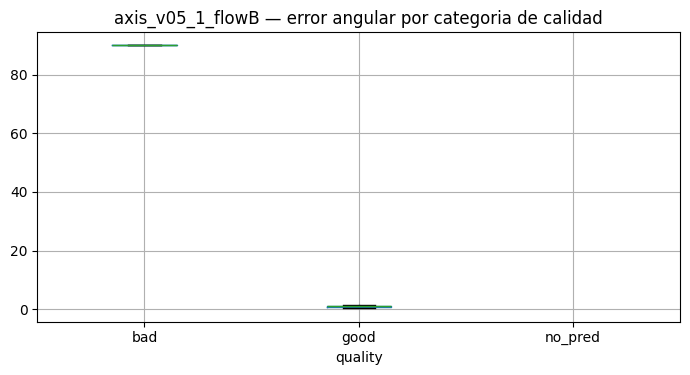

In [16]:
EXPERIMENT_FOR_OBJECT_DETAIL = "axis_v05_1_flowB"

obj_detail = load_object_breakdown(EXPERIMENT_FOR_OBJECT_DETAIL)
display(obj_detail.head(10))

fig, ax = plt.subplots(figsize=(7, 4))
obj_detail.boxplot(column="angular_error_deg", by="quality", ax=ax)
ax.set_title(f"{EXPERIMENT_FOR_OBJECT_DETAIL} — error angular por categoria de calidad")
plt.suptitle("")
plt.tight_layout()
plt.show()


## 9. Tabla resumen final: mejor configuracion por tipo de simetria

Combina lo anterior en una unica tabla comparativa, una fila por tipo de simetria, con la mejor configuracion segun `combined_rank` (ranking que ya pondera AUC y error/SDE — ver `compare_results.py`).

In [17]:
summary_rows = []
for sym_type, ranking_name in [("axis_sym", "axis_sym_ranking_combined"),
                                ("plane_sym", "plane_sym_ranking_combined")]:
    df = rankings[ranking_name]
    best = df.sort_values("combined_rank", ascending=True).iloc[0]
    summary_rows.append({
        "symmetry_type": sym_type,
        "experiment": best["experiment"],
        "flow": best["flow"],
        "clustering": best["clustering"],
        "patch_size": best["patch_size"],
        "method": best["method"],
        "n_views": best["n_views"],
        "auc_angular": best["auc_angular"],
    })

pd.DataFrame(summary_rows)


,symmetry_type,experiment,flow,clustering,patch_size,method,n_views,auc_angular
0,axis_sym,axis_v05_1_flowC_p5,C,none,5,svd_sde,26,0.4369
1,plane_sym,plane_v04_p5,A,none,5,svd_sde,6,0.3464
